# 3C XGBoost Regressor

**Project:** Predictive Modeling of US Used Vehicle Prices
**Course:** ENGR422 Applied Machine Learning
**Author:** Eren Acar Başaran (83179)

This notebook covers the XGBoost regressor for Work Package 3.

Deliverable D3.2 Tuned Ensemble Models, XGBoost portion.


## 3C.1 Imports and load preprocessed data

Load the train split and the tree preprocessor from notebook 02. The tree preprocessor passes year and odometer through unchanged because tree models do not need scaling.

Code organization note. We import shared helpers from src/utils.py for load_train, load_preprocessor, MODELS_DIR and RANDOM_STATE. All model notebooks use the same loaders so the splits and preprocessor instances are byte identical across the comparison.

The flag below toggles the early stopping ablation in 3C.5.1. Set to False to skip it and only train the random search model.


In [1]:
import sys
import time

import joblib
import numpy as np
import pandas as pd
from sklearn.base import clone
from sklearn.pipeline import Pipeline

import xgboost as xgb

# src has shared utilities and custom transformer classes that joblib needs.
sys.path.insert(0, "../src")
import preprocessing  # noqa: F401
from utils import load_train, load_preprocessor, MODELS_DIR, RANDOM_STATE

# Toggle the early stopping ablation in 3C.4.1. Set False to skip.
RUN_EARLY_STOP_ABLATION = True

X_train, y_train = load_train()

# Tree preprocessor. Trees do not need scaling.
preprocessor_tree = load_preprocessor("tree")

print(f"X_train: {X_train.shape}")
print(f"y_train: {y_train.shape}")
print(f"Raw features ({X_train.shape[1]}): {list(X_train.columns)}")
print(f"Loaded preprocessor: {type(preprocessor_tree).__name__} "
      f"with steps {[name for name, _ in preprocessor_tree.steps]}")
print(f"xgboost version: {xgb.__version__}")


X_train: (305141, 12)
y_train: (305141,)
Raw features (12): ['year', 'manufacturer', 'model', 'condition', 'fuel', 'odometer', 'title_status', 'transmission', 'drive', 'type', 'paint_color', 'state']
Loaded preprocessor: Pipeline with steps ['impute', 'encode']
xgboost version: 3.2.0


## 3C.2 Model setup

Set up a baseline XGBoost regressor in a pipeline. The pipeline has two steps. First the tree preprocessor. Second the XGBoost estimator.

We use tree_method hist which is faster than the exact method on a dataset this size. The objective is squared error. For the baseline we use library defaults. Tuning happens in 3C.4.


In [2]:
# Baseline XGBoost. Reference point for 3C.3.
# tree_method hist is fast on big data. objective is squared error.
xgb_baseline = xgb.XGBRegressor(
    tree_method="hist",
    objective="reg:squarederror",
    n_jobs=-1,
    random_state=RANDOM_STATE,
)

# Clone the preprocessor. CV folds refit cleanly. No target leakage.
xgb_pipeline = Pipeline([
    ("prep", clone(preprocessor_tree)),
    ("est",  xgb_baseline),
])

xgb_pipeline


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('est', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('impute', ...), ('encode', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('year_imp', ...), ('odo_imp', ...), ...]"
,"transform_input transform

## 3C.3 Baseline training

Fit XGBoost with default hyperparameters and run 5 fold cross validation. This gives the no tuning reference number for 3C.4.


In [3]:
from sklearn.model_selection import cross_validate

# Fit baseline on full train. Reused in 3C.6 and 3C.7.
print(f"Fitting baseline XGBoost on {X_train.shape[0]:,} rows ...")
t0 = time.perf_counter()
xgb_pipeline.fit(X_train, y_train)
baseline_fit_time = time.perf_counter() - t0
print(f"  done in {baseline_fit_time:.1f}s")

# 5 fold CV with MAE and R squared. Clones per fold so no leakage.
print("\n5-fold cross-validation (default hyperparameters) ...")
res = cross_validate(
    xgb_pipeline, X_train, y_train,
    cv=5,
    scoring={"mae": "neg_mean_absolute_error", "r2": "r2"},
    n_jobs=-1,
)

baseline_mae = -res["test_mae"]   # back to positive dollars
baseline_r2  =  res["test_r2"]

print(f"\n  MAE per fold: " + ", ".join(f"${m:>7,.0f}" for m in baseline_mae))
print(f"  R^2 per fold: " + ", ".join(f" {r:.4f}" for r in baseline_r2))
print(f"\nBaseline summary:")
print(f"  CV MAE = ${baseline_mae.mean():,.2f} \u00b1 ${baseline_mae.std():,.2f}")
print(f"  CV R^2 = {baseline_r2.mean():.4f} \u00b1 {baseline_r2.std():.4f}")


Fitting baseline XGBoost on 305,141 rows ...


  done in 3.4s

5-fold cross-validation (default hyperparameters) ...



  MAE per fold: $  3,219, $  3,236, $  3,261, $  3,256, $  3,258
  R^2 per fold:  0.8485,  0.8444,  0.8425,  0.8483,  0.8406

Baseline summary:
  CV MAE = $3,246.08 ± $16.09
  CV R^2 = 0.8449 ± 0.0031


## 3C.4 Hyperparameter tuning

Tune 8 XGBoost hyperparameters with RandomizedSearchCV. We use industry standard Kaggle competition ranges. The search uses 40 random combinations and 5 fold CV. Score is mean absolute error. Random sampling beats exhaustive grid in high dim spaces (Bergstra and Bengio 2012).

Sampled space:
- n_estimators, randint 500 to 3000. Wide ceiling because gradient boosting often needs many trees with low learning rate.
- max_depth, randint 3 to 9. Industry standard XGBoost range.
- learning_rate, loguniform 0.005 to 0.3. Low end pairs with the wide n_estimators range.
- subsample and colsample_bytree, uniform 0.5 to 1.0.
- min_child_weight, randint 1 to 10.
- reg_alpha, loguniform 0.001 to 10.
- reg_lambda, loguniform 0.01 to 100.

After fitting, refit True retrains the best estimator on the full training set.


Starting RandomizedSearchCV: 40 samples x 5 folds = 200 fits ...
Fitting 5 folds for each of 40 candidates, totalling 200 fits


  done in 18.2 min

Best CV MAE: $2,134.90
Best params:
  colsample_bytree   0.909
  learning_rate      0.1696
  max_depth          9
  min_child_weight   6
  n_estimators       1979
  reg_alpha          0.1369
  reg_lambda         0.8696
  subsample          0.8462

Improvement over baseline (default hyperparameters):
  baseline CV MAE = $3,246.08
  tuned    CV MAE = $2,134.90
  delta           = $1,111.19


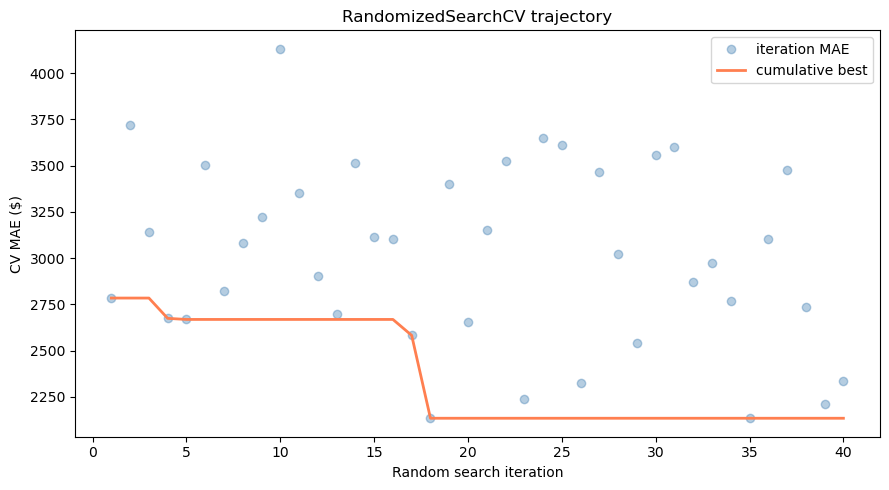

In [4]:
from scipy.stats import loguniform, randint, uniform
from sklearn.model_selection import RandomizedSearchCV

# Search budget. 40 samples x 5 folds = 200 fits.
N_ITER = 40

# Industry standard Kaggle ranges for XGBoost on tabular regression.
param_distributions = {
    "est__n_estimators":     randint(500, 3000),     # typical Kaggle range
    "est__max_depth":        randint(3, 10),          # 3 to 9
    "est__learning_rate":    loguniform(0.005, 0.3),  # small LR pairs with many trees
    "est__subsample":        uniform(0.5, 0.5),       # 0.5 to 1.0
    "est__colsample_bytree": uniform(0.5, 0.5),       # 0.5 to 1.0
    "est__min_child_weight": randint(1, 10),
    "est__reg_alpha":        loguniform(1e-3, 10.0),  # 0.001 to 10
    "est__reg_lambda":       loguniform(1e-2, 100.0), # 0.01 to 100
}

# Fresh pipeline. Clone refits per fold. Inner n_jobs=1 to avoid oversubscription.
xgb_search = RandomizedSearchCV(
    Pipeline([
        ("prep", clone(preprocessor_tree)),
        ("est",  xgb.XGBRegressor(
            tree_method="hist",
            objective="reg:squarederror",
            n_jobs=1,
            random_state=RANDOM_STATE,
        )),
    ]),
    param_distributions=param_distributions,
    n_iter=N_ITER,
    scoring="neg_mean_absolute_error",
    cv=5,
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=1,
    refit=True,
    return_train_score=True,   # used in 3C.7
)

print(f"Starting RandomizedSearchCV: {N_ITER} samples x 5 folds = {N_ITER * 5} fits ...")
t0 = time.perf_counter()
xgb_search.fit(X_train, y_train)
search_time = time.perf_counter() - t0
print(f"  done in {search_time/60:.1f} min")

best_mae = -xgb_search.best_score_
print(f"\nBest CV MAE: ${best_mae:,.2f}")
print("Best params:")
for k, v in xgb_search.best_params_.items():
    val = f"{v:.4g}" if isinstance(v, float) else v
    print(f"  {k.removeprefix('est__'):<18} {val}")

# Compare to baseline from 3C.3.
print(f"\nImprovement over baseline (default hyperparameters):")
print(f"  baseline CV MAE = ${baseline_mae.mean():,.2f}")
print(f"  tuned    CV MAE = ${best_mae:,.2f}")
print(f"  delta           = ${baseline_mae.mean() - best_mae:,.2f}")


# Tuning trajectory. Cumulative best CV MAE over the search.
import matplotlib.pyplot as plt
mae_per_iter = -xgb_search.cv_results_["mean_test_score"]
best_so_far  = np.minimum.accumulate(mae_per_iter)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(range(1, len(mae_per_iter) + 1), mae_per_iter, "o", alpha=0.4,
        color="steelblue", label="iteration MAE")
ax.plot(range(1, len(best_so_far) + 1), best_so_far, "-", color="coral",
        linewidth=2, label="cumulative best")
ax.set_xlabel("Random search iteration")
ax.set_ylabel("CV MAE ($)")
ax.set_title("RandomizedSearchCV trajectory")
ax.legend()
plt.tight_layout()
plt.show()


## 3C.5 Train best model

Use the best estimator from the search. Run a final 5 fold CV with both MAE and R squared. Make the predicted vs actual scatter and the residual histogram from out of fold predictions.


5-fold CV on the tuned XGBoost ...



  MAE per fold: $  2,118, $  2,128, $  2,159, $  2,126, $  2,143
  R^2 per fold:  0.8970,  0.8967,  0.8897,  0.8982,  0.8927

Tuned XGBoost (final):
  CV MAE = $2,134.90 ± $14.43
  CV R^2 = 0.8948 ± 0.0032

Generating out-of-fold predictions for diagnostic plots ...


  done in 1.4 min


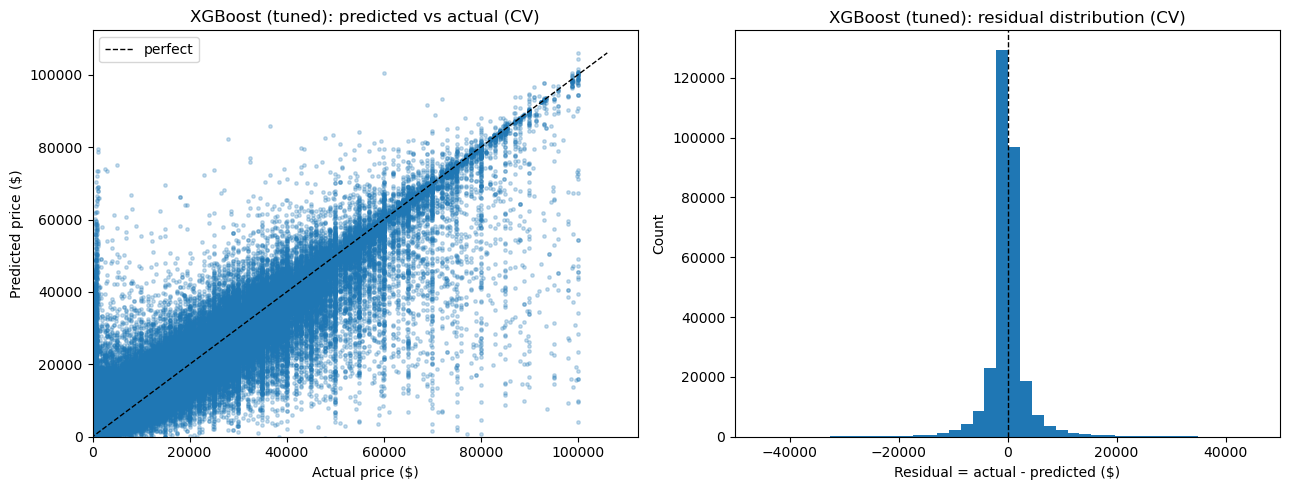

In [5]:
# best_estimator_ is already refit on full X_train.
best_pipeline = xgb_search.best_estimator_

# Final 5 fold CV with chosen hyperparameters.
print("5-fold CV on the tuned XGBoost ...")
res = cross_validate(
    best_pipeline, X_train, y_train,
    cv=5,
    scoring={"mae": "neg_mean_absolute_error", "r2": "r2"},
    n_jobs=-1,
    return_train_score=True,
)

tuned_mae       = -res["test_mae"]
tuned_r2        =  res["test_r2"]
tuned_train_mae = -res["train_mae"]   # used in 3C.7

print(f"\n  MAE per fold: " + ", ".join(f"${m:>7,.0f}" for m in tuned_mae))
print(f"  R^2 per fold: " + ", ".join(f" {r:.4f}" for r in tuned_r2))
print(f"\nTuned XGBoost (final):")
print(f"  CV MAE = ${tuned_mae.mean():,.2f} \u00b1 ${tuned_mae.std():,.2f}")
print(f"  CV R^2 = {tuned_r2.mean():.4f} \u00b1 {tuned_r2.std():.4f}")


# Diagnostic plots on out of fold predictions. No test set leakage.
from sklearn.model_selection import cross_val_predict
from utils import plot_pred_vs_actual, plot_residuals

print("\nGenerating out-of-fold predictions for diagnostic plots ...")
t0 = time.perf_counter()
y_pred_cv = cross_val_predict(best_pipeline, X_train, y_train, cv=5, n_jobs=-1)
print(f"  done in {(time.perf_counter() - t0)/60:.1f} min")

import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
plot_pred_vs_actual(y_train, y_pred_cv, ax=axes[0],
                    title="XGBoost (tuned): predicted vs actual (CV)")
plot_residuals(y_train, y_pred_cv, ax=axes[1],
               title="XGBoost (tuned): residual distribution (CV)")
# Prices are non negative. Pin axes to start at 0.
axes[0].set_xlim(left=0)
axes[0].set_ylim(bottom=0)
# Limit residual view to +/- 50k for readability.
axes[1].set_xlim(-50_000, 50_000)
plt.tight_layout()
plt.show()


## 3C.5.1 Early stopping ablation

This section is optional. It runs only if RUN_EARLY_STOP_ABLATION is True at the top of 3C.1.

We test early stopping as a different way to pick the tree count. Both setups use the same hyperparameters that random search found in 3C.4. Only the tree count is chosen differently.

Random search picks a fixed number of trees from the search range. Early stopping watches a small validation set during training and stops adding trees when the error stops getting better.

The cell below runs a 5 fold cross validation for the early stopping setup. Then it fits one final model on all training data and saves it as models/xgboost_early_stop.pkl.

The full vs early stopping comparison on the held out test set lives in 4.2.2 of the evaluation notebook.


In [6]:
if RUN_EARLY_STOP_ABLATION:
    from sklearn.model_selection import KFold, train_test_split
    from sklearn.metrics import mean_absolute_error

    # Random search best params. Drop n_estimators since early stopping picks it.
    rs_best = {k.removeprefix("est__"): v for k, v in xgb_search.best_params_.items()}
    rs_best.pop("n_estimators", None)

    # Shared XGB args.
    common = dict(
        tree_method="hist",
        objective="reg:squarederror",
        n_jobs=-1,
        random_state=RANDOM_STATE,
        **rs_best,
    )

    print("Running 5 fold CV for early stopping setup...")
    kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    es_fold_mae, trees_per_fold = [], []
    for fold_idx, (tr_idx, val_idx) in enumerate(kf.split(X_train), start=1):
        X_tr_raw  = X_train.iloc[tr_idx]
        X_val_raw = X_train.iloc[val_idx]
        y_tr  = y_train.values[tr_idx]
        y_val = y_train.values[val_idx]

        # Fresh preprocessor fit on fold train only.
        prep = clone(preprocessor_tree)
        X_tr_proc  = prep.fit_transform(X_tr_raw, y_tr)
        X_val_proc = prep.transform(X_val_raw)

        # Inner train val split for early stopping.
        X_in_tr, X_in_val, y_in_tr, y_in_val = train_test_split(
            X_tr_proc, y_tr, test_size=0.15, random_state=RANDOM_STATE,
        )

        m = xgb.XGBRegressor(n_estimators=2000, early_stopping_rounds=50, eval_metric="mae", **common)
        m.fit(X_in_tr, y_in_tr, eval_set=[(X_in_val, y_in_val)], verbose=False)
        pred = m.predict(X_val_proc)
        es_fold_mae.append(mean_absolute_error(y_val, pred))
        trees_per_fold.append(m.best_iteration + 1)
        print(f"  fold {fold_idx}: MAE = ${es_fold_mae[-1]:,.0f}, trees used = {trees_per_fold[-1]}")

    es_cv_mae = float(np.mean(es_fold_mae))
    es_cv_std = float(np.std(es_fold_mae))
    print(f"\nEarly stopping CV MAE: ${es_cv_mae:,.2f} +/- ${es_cv_std:,.2f}")
    print(f"Random search   CV MAE: ${tuned_mae.mean():,.2f} +/- ${tuned_mae.std():,.2f}")
    print(f"Delta: ${es_cv_mae - tuned_mae.mean():+,.2f}")

    # Refit on full training data. Save the pipeline.
    prep_full = clone(preprocessor_tree)
    X_full_proc = prep_full.fit_transform(X_train, y_train)
    X_in_tr, X_in_val, y_in_tr, y_in_val = train_test_split(
        X_full_proc, y_train.values, test_size=0.15, random_state=RANDOM_STATE,
    )
    final_es = xgb.XGBRegressor(n_estimators=2000, early_stopping_rounds=50, eval_metric="mae", **common)
    final_es.fit(X_in_tr, y_in_tr, eval_set=[(X_in_val, y_in_val)], verbose=False)
    print(f"\nFinal early stopping model used {final_es.best_iteration + 1} trees")

    es_pipeline = Pipeline([("prep", prep_full), ("est", final_es)])
    joblib.dump(es_pipeline, MODELS_DIR / "xgboost_early_stop.pkl")
    print(f"Saved -> models/xgboost_early_stop.pkl")
else:
    print("RUN_EARLY_STOP_ABLATION = False -- skipping early stopping ablation")


Running 5 fold CV for early stopping setup...


  fold 1: MAE = $2,170, trees used = 1999


  fold 2: MAE = $2,195, trees used = 2000


  fold 3: MAE = $2,213, trees used = 2000


  fold 4: MAE = $2,162, trees used = 2000


  fold 5: MAE = $2,195, trees used = 1999

Early stopping CV MAE: $2,187.07 +/- $18.71
Random search   CV MAE: $2,134.90 +/- $14.43
Delta: $+52.17



Final early stopping model used 2000 trees


Saved -> models/xgboost_early_stop.pkl


## 3C.6 Feature importance

XGBoost exposes feature_importances_ on the fitted estimator. Default is gain importance. We extract it from the tuned model and plot the top 15 with a shared utils helper.

Feature names are built manually from the encode ColumnTransformer. The saved preprocessor has a FunctionTransformer that does not expose get_feature_names_out so we walk the transformers manually.


Top 15 features by XGBoost gain importance:
                  feature  importance
            target__model    0.195906
               year__year    0.082743
  ohe__transmission_other    0.070622
            ohe__fuel_gas    0.067748
          ohe__fuel_other    0.056588
           ohe__drive_fwd    0.050439
ohe__title_status_salvage    0.040337
ohe__title_status_rebuilt    0.038460
ohe__title_status_missing    0.036772
         ohe__fuel_hybrid    0.027564
          ohe__type_truck    0.025865
    ohe__type_convertible    0.025091
           ohe__drive_rwd    0.023687
          ohe__type_other    0.021609
     target__manufacturer    0.021304


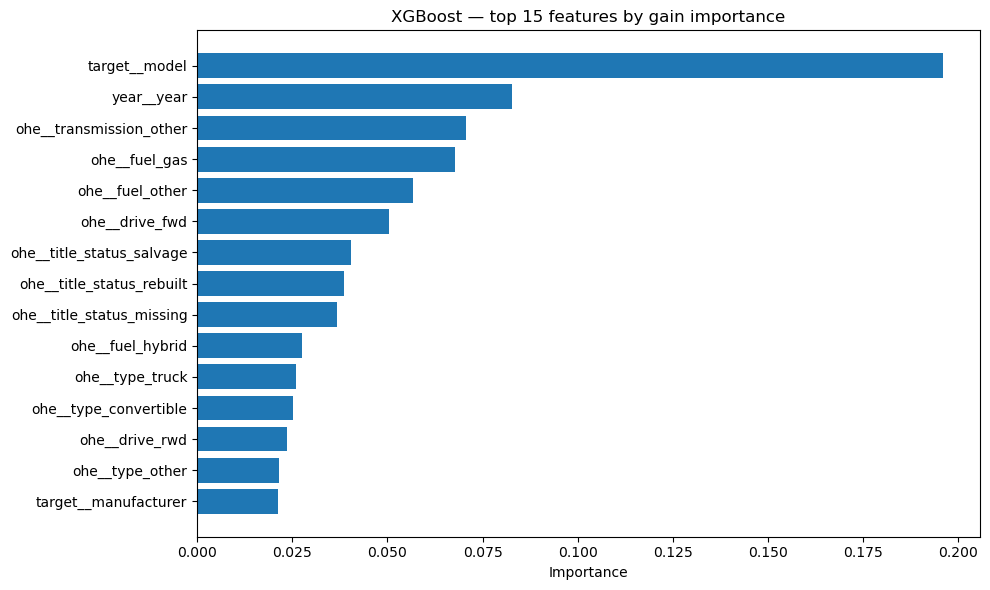

In [7]:
from utils import plot_feature_importances

# Build feature names from the encode ColumnTransformer.
encode = best_pipeline.named_steps["prep"].named_steps["encode"]
_parts = []
for tname, trans, cols in encode.transformers_:
    if tname == "ohe":
        ohe_names = encode.named_transformers_["ohe"].get_feature_names_out(cols)
        _parts.extend(f"ohe__{n}" for n in ohe_names)
    else:
        _parts.extend(f"{tname}__{c}" for c in cols)
feat_names = np.asarray(_parts)

importances = best_pipeline.named_steps["est"].feature_importances_
assert len(importances) == len(feat_names), \
    f"importance count {len(importances)} != feature-name count {len(feat_names)}"

# Top 15 table.
top_idx = np.argsort(importances)[::-1][:15]
print("Top 15 features by XGBoost gain importance:")
print(pd.DataFrame({
    "feature":    feat_names[top_idx],
    "importance": importances[top_idx],
}).to_string(index=False))

# Plot via utils for consistent visuals.
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(10, 6))
plot_feature_importances(importances, feat_names, n=15, ax=ax,
                         title="XGBoost — top 15 features by gain importance")
plt.tight_layout()
plt.show()


## 3C.7 Overfitting analysis

Compare the train MAE and CV MAE from 3C.5. A small gap means the model generalizes well. A big gap means overfitting.

Rule of thumb. Below 10 percent of CV MAE is comfortable. 10 to 25 percent is acceptable. Above 25 percent suggests too little regularization or too deep trees.


In [8]:
gap        = tuned_train_mae.mean() - tuned_mae.mean()
gap_pct    = 100 * gap / tuned_mae.mean()

print(f"Train MAE (CV folds, mean):  ${tuned_train_mae.mean():,.2f}")
print(f"CV    MAE (CV folds, mean):  ${tuned_mae.mean():,.2f}")
print(f"Gap (CV - train):            ${gap:,.2f}  ({gap_pct:+.1f}% of CV MAE)")

if gap_pct < 10:
    verdict = "comfortable -- model generalizes well"
elif gap_pct < 25:
    verdict = "acceptable -- mild overfit, typical for boosted trees"
else:
    verdict = "concerning -- consider tighter regularization (higher reg_lambda, lower max_depth, fewer n_estimators)"
print(f"\nVerdict: {verdict}")


Train MAE (CV folds, mean):  $673.51
CV    MAE (CV folds, mean):  $2,134.90
Gap (CV - train):            $-1,461.39  (-68.5% of CV MAE)

Verdict: comfortable -- model generalizes well


## 3C.8 Learning curves

This section is optional and tagged veryNiceToHave.

We plot train MAE and CV MAE against training set size. Two reads.

If the curves converge then more data has stopped helping. The model is not data limited.

If the curves keep diverging then the gap would close with more data or with more regularization.

We use cv 3 and 4 train sizes to keep wall clock under 20 minutes.


Computing learning curves (4 train sizes x 3 folds = 12 fits) ...


  done in 1.7 min


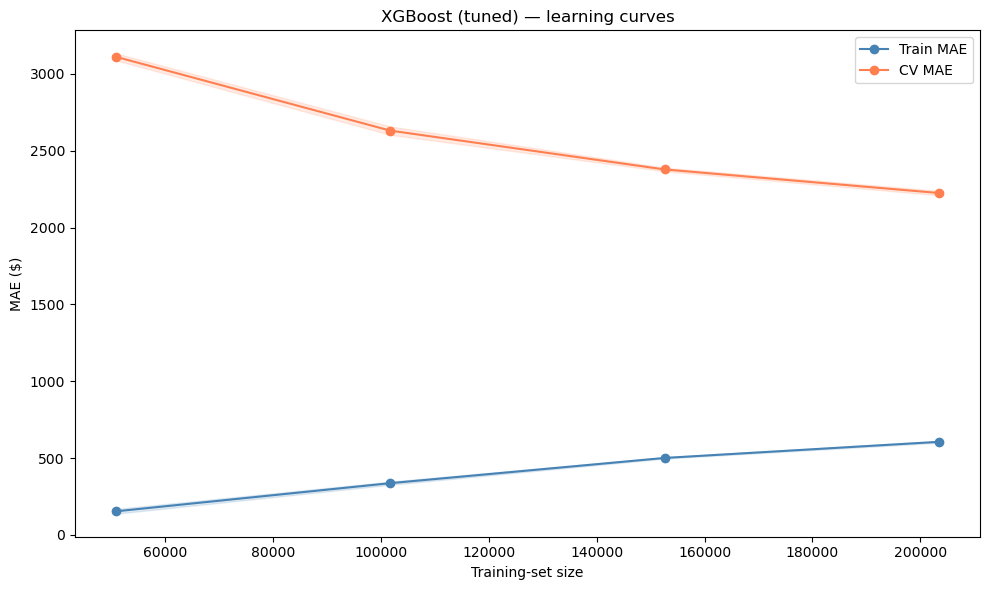

In [9]:
from sklearn.model_selection import learning_curve

print("Computing learning curves (4 train sizes x 3 folds = 12 fits) ...")
t0 = time.perf_counter()
train_sizes_abs, train_scores, test_scores = learning_curve(
    best_pipeline, X_train, y_train,
    train_sizes=np.linspace(0.25, 1.0, 4),
    cv=3,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
    random_state=RANDOM_STATE,
)
print(f"  done in {(time.perf_counter() - t0)/60:.1f} min")

train_m = -train_scores.mean(axis=1); train_s = train_scores.std(axis=1)
test_m  = -test_scores.mean(axis=1);  test_s  = test_scores.std(axis=1)

import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(10, 6))
ax.fill_between(train_sizes_abs, train_m - train_s, train_m + train_s, alpha=0.15, color="steelblue")
ax.fill_between(train_sizes_abs, test_m - test_s,   test_m + test_s,   alpha=0.15, color="coral")
ax.plot(train_sizes_abs, train_m, "o-", color="steelblue", label="Train MAE")
ax.plot(train_sizes_abs, test_m,  "o-", color="coral",     label="CV MAE")
ax.set_xlabel("Training-set size")
ax.set_ylabel("MAE ($)")
ax.set_title("XGBoost (tuned) — learning curves")
ax.legend()
plt.tight_layout()
plt.show()


## 3C.9 Feature selection experiment

This section is optional and tagged niceToHave.

Refit the tuned XGBoost from 3C.5 on a reduced feature set and save it as models/xgboost_reduced.pkl. The full vs reduced test set comparison lives in 4.2.2 of the evaluation notebook.

We use SelectFromModel with threshold median. This keeps the top half of the features by importance.


Refitting XGBoost on reduced (top-half) feature set ...


  done in 11.1s

Kept 16/32 features:
  - year__year
  - odo__odometer
  - ohe__fuel_gas
  - ohe__fuel_other
  - ohe__transmission_other
  - ohe__drive_fwd
  - ohe__drive_rwd
  - ohe__type_hatchback
  - ohe__type_other
  - ohe__type_pickup
  - ohe__type_truck
  - ohe__type_van
  - ohe__title_status_rebuilt
  - ohe__title_status_salvage
  - target__manufacturer
  - target__model



Reduced-feature CV MAE (3-fold): $2,421.01 ± $16.47
Tuned full-feature CV MAE (5-fold, S3C.5): $2,134.90 ± $14.43



Saved -> models/xgboost_reduced.pkl


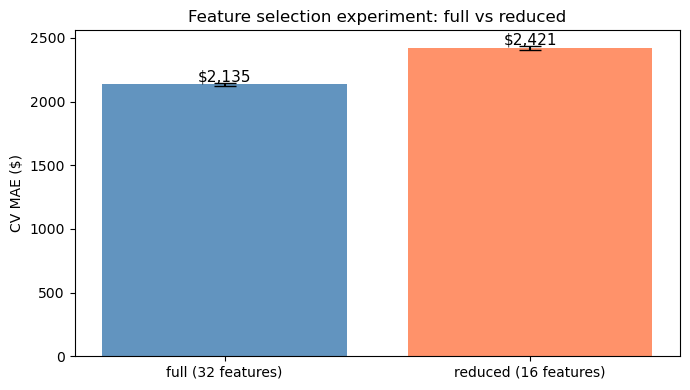

In [10]:
from sklearn.feature_selection import SelectFromModel

# Strip 'est__' prefix so params plug into a fresh XGBRegressor.
best_params_clean = {k.removeprefix("est__"): v for k, v in xgb_search.best_params_.items()}

# Refit on the reduced feature set.
# SelectFromModel with threshold median keeps the top half of features.
# We pass a fresh unfitted XGBRegressor so the selector fits inside the pipeline.
reduced_pipeline = Pipeline([
    ("prep", clone(preprocessor_tree)),
    ("select", SelectFromModel(
        estimator=xgb.XGBRegressor(
            tree_method="hist",
            n_jobs=-1,
            random_state=RANDOM_STATE,
            n_estimators=200,
            max_depth=6,
        ),
        threshold="median",
    )),
    ("est", xgb.XGBRegressor(
        tree_method="hist",
        objective="reg:squarederror",
        n_jobs=-1,
        random_state=RANDOM_STATE,
        **best_params_clean,
    )),
])

print("Refitting XGBoost on reduced (top-half) feature set ...")
t0 = time.perf_counter()
reduced_pipeline.fit(X_train, y_train)
print(f"  done in {time.perf_counter() - t0:.1f}s")

# Features kept by the selector.
selected_mask = reduced_pipeline.named_steps["select"].get_support()
selected_features = feat_names[selected_mask]
print(f"\nKept {selected_mask.sum()}/{len(feat_names)} features:")
for f in selected_features:
    print(f"  - {f}")

# Quick 3 fold CV sanity check.
res_reduced = cross_validate(
    reduced_pipeline, X_train, y_train,
    cv=3,
    scoring={"mae": "neg_mean_absolute_error"},
    n_jobs=-1,
)
reduced_mae = -res_reduced["test_mae"]
print(f"\nReduced-feature CV MAE (3-fold): ${reduced_mae.mean():,.2f} \u00b1 ${reduced_mae.std():,.2f}")
print(f"Tuned full-feature CV MAE (5-fold, S3C.5): ${tuned_mae.mean():,.2f} \u00b1 ${tuned_mae.std():,.2f}")

# Save. Full vs reduced test comparison happens in 04.
joblib.dump(reduced_pipeline, MODELS_DIR / "xgboost_reduced.pkl")
print(f"\nSaved -> models/xgboost_reduced.pkl")


# Quick CV MAE bar for full vs reduced. The test set comparison is in 04.
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(7, 4))
labels = [f"full ({len(feat_names)} features)",
          f"reduced ({selected_mask.sum()} features)"]
values = [tuned_mae.mean(), reduced_mae.mean()]
errors = [tuned_mae.std(),  reduced_mae.std()]
bars = ax.bar(labels, values, yerr=errors, capsize=8,
              color=["steelblue", "coral"], alpha=0.85)
for bar, v in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, v, f"${v:,.0f}",
            ha="center", va="bottom", fontsize=11)
ax.set_ylabel("CV MAE ($)")
ax.set_title("Feature selection experiment: full vs reduced")
plt.tight_layout()
plt.show()


## 3C.10 Save model

Save the tuned XGBoost pipeline as models/xgboost.pkl. Notebook 04 loads this exact filename. Save the search summary as models/xgb_tuning_results.json so 04 can compare it side by side with the random forest tuning summary.


In [11]:
# Notebook 04 loads this filename.
save_path = MODELS_DIR / "xgboost.pkl"
joblib.dump(best_pipeline, save_path)
print(f"Saved -> models/{save_path.name}")

# Tuning results JSON for 04.
import json as _json
tuning_results = {
    "best_params": best_params_clean,
    "best_cv_mae":     float(tuned_mae.mean()),
    "best_cv_mae_std": float(tuned_mae.std()),
    "baseline_cv_mae": float(baseline_mae.mean()),
    "improvement_over_baseline": float(baseline_mae.mean() - tuned_mae.mean()),
    "n_iter": int(xgb_search.cv_results_["mean_test_score"].shape[0]),
    "search_time_seconds": float(search_time),
}
with open(MODELS_DIR / "xgb_tuning_results.json", "w") as f:
    _json.dump(tuning_results, f, indent=2)
print(f"Saved -> models/xgb_tuning_results.json")


Saved -> models/xgboost.pkl
Saved -> models/xgb_tuning_results.json
